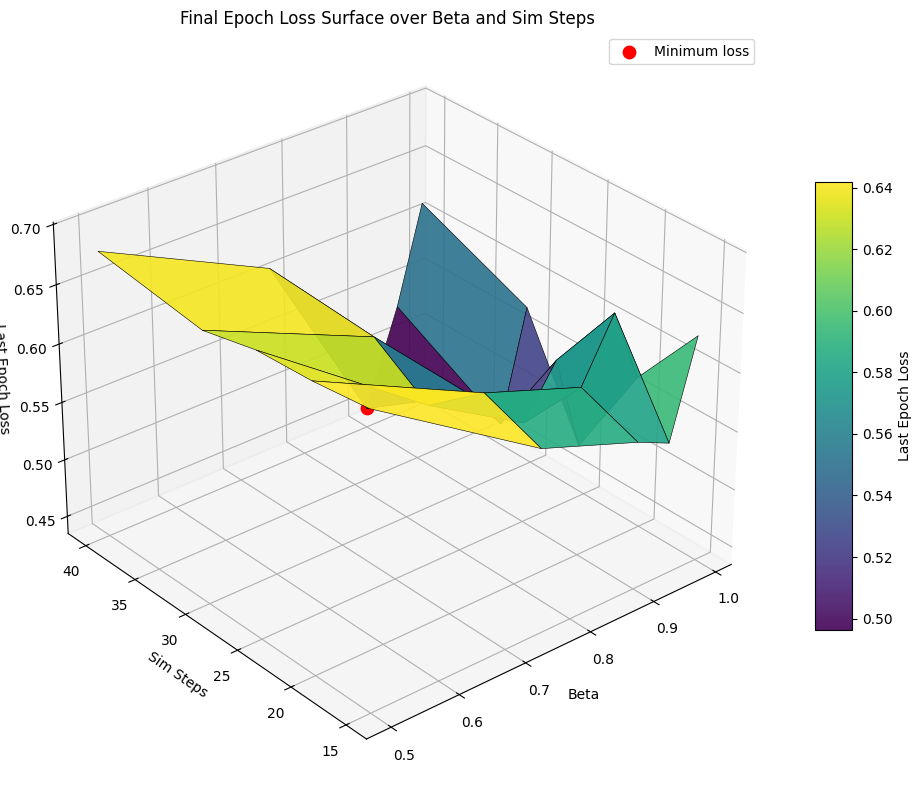

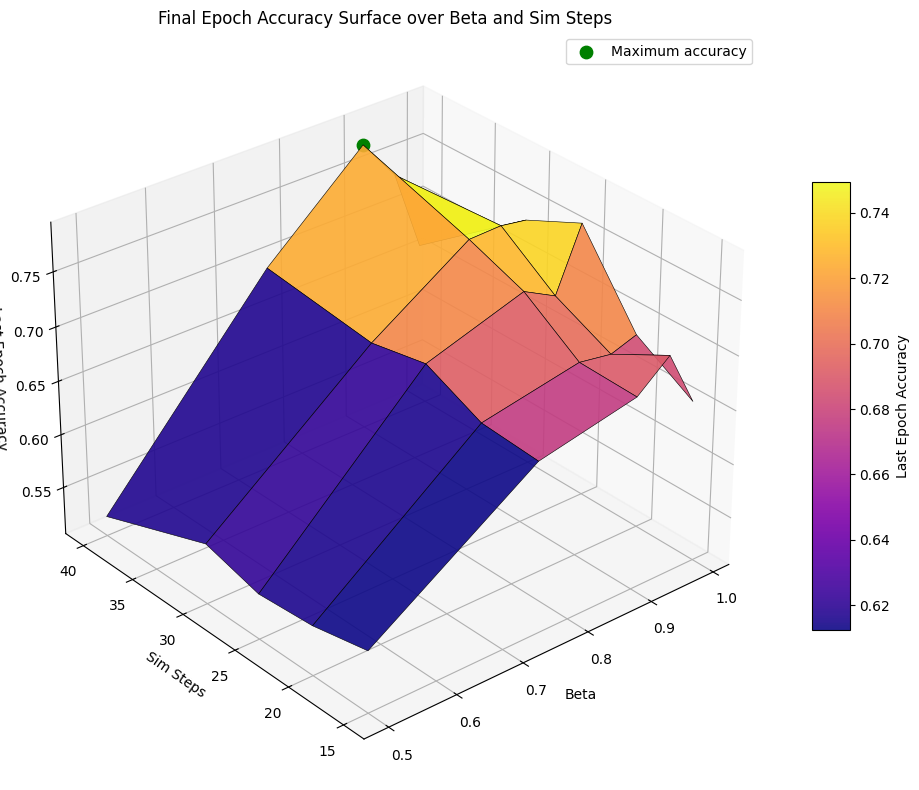

=== Best Parameter Combination (Minimum Last-Epoch Loss) ===
Beta: 0.9
Sim Steps: 40
Last Epoch Loss: 0.451578
File: hypr-1_2026-04-27_20-51-03_e-10_s-40_spatial.json

=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===
Beta: 0.9
Sim Steps: 40
Last Epoch Accuracy: 0.776000
File: hypr-1_2026-04-27_20-51-03_e-10_s-40_spatial.json

Accuracy key(s) used: ['epoch_train_accuracy']


In [8]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Build 3D surfaces of final-epoch metrics over (beta, sim_steps).
import numpy as np

files = sorted(glob('../output_results/E_sent/hypr-1/hypr-1_*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

# (beta, sim_steps, last_epoch_loss, last_epoch_accuracy, file_name, acc_key_used)
records = []
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    beta_raw = training_config.get('beta')
    sim_steps_raw = training_config.get('sim_steps')
    epoch_losses = results.get('epoch_train_loss', [])

    accuracy_key_candidates = [
        'epoch_train_accuracy',
        'epoch_accuracy',
        'epoch_val_accuracy',
        'epoch_test_accuracy',
    ]
    last_acc = None
    acc_key_used = None
    for key in accuracy_key_candidates:
        series = results.get(key, [])
        if isinstance(series, list) and series:
            last_acc = float(series[-1])
            acc_key_used = key
            break

    if beta_raw is None or sim_steps_raw is None or not epoch_losses or last_acc is None:
        continue

    beta = float(beta_raw)
    sim_steps = float(sim_steps_raw)
    last_epoch_loss = float(epoch_losses[-1])
    records.append((beta, sim_steps, last_epoch_loss, last_acc, Path(file).name, acc_key_used))

if not records:
    raise ValueError(
        'No valid records found with beta, sim_steps, epoch_train_loss, and an accuracy series.'
    )

betas = sorted({r[0] for r in records})
sim_steps_vals = sorted({r[1] for r in records})

# Create rectangular grids for both surfaces.
X, Y = np.meshgrid(betas, sim_steps_vals)
Z_loss = np.full_like(X, np.nan, dtype=float)
Z_acc = np.full_like(X, np.nan, dtype=float)

for beta, sim_steps, loss, acc, _, _ in records:
    x_idx = betas.index(beta)
    y_idx = sim_steps_vals.index(sim_steps)
    Z_loss[y_idx, x_idx] = loss
    Z_acc[y_idx, x_idx] = acc

fig1 = plt.figure(figsize=(11, 8))
ax1 = fig1.add_subplot(111, projection='3d')
surface_loss = ax1.plot_surface(
    X, Y, Z_loss, cmap='viridis', edgecolor='k', linewidth=0.4, alpha=0.9
)
fig1.colorbar(surface_loss, ax=ax1, shrink=0.6, aspect=12, label='Last Epoch Loss')

best_beta, best_sim_steps, best_loss, _, best_loss_file, _ = min(records, key=lambda x: x[2])
ax1.scatter(best_beta, best_sim_steps, best_loss, color='red', s=80, label='Minimum loss')
ax1.legend()

ax1.set_title('Final Epoch Loss Surface over Beta and Sim Steps')
ax1.set_xlabel('Beta')
ax1.set_ylabel('Sim Steps')
ax1.set_zlabel('Last Epoch Loss')
ax1.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(11, 8))
ax2 = fig2.add_subplot(111, projection='3d')
surface_acc = ax2.plot_surface(
    X, Y, Z_acc, cmap='plasma', edgecolor='k', linewidth=0.4, alpha=0.9
)
fig2.colorbar(surface_acc, ax=ax2, shrink=0.6, aspect=12, label='Last Epoch Accuracy')

best_beta_acc, best_sim_steps_acc, _, best_acc, best_acc_file, _ = max(records, key=lambda x: x[3])
ax2.scatter(best_beta_acc, best_sim_steps_acc, best_acc, color='green', s=80, label='Maximum accuracy')
ax2.legend()

ax2.set_title('Final Epoch Accuracy Surface over Beta and Sim Steps')
ax2.set_xlabel('Beta')
ax2.set_ylabel('Sim Steps')
ax2.set_zlabel('Last Epoch Accuracy')
ax2.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

print('=== Best Parameter Combination (Minimum Last-Epoch Loss) ===')
print(f'Beta: {best_beta}')
print(f'Sim Steps: {best_sim_steps:g}')
print(f'Last Epoch Loss: {best_loss:.6f}')
print(f'File: {best_loss_file}')

print('\n=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===')
print(f'Beta: {best_beta_acc}')
print(f'Sim Steps: {best_sim_steps_acc:g}')
print(f'Last Epoch Accuracy: {best_acc:.6f}')
print(f'File: {best_acc_file}')

used_acc_keys = sorted({r[5] for r in records})
print(f'\nAccuracy key(s) used: {used_acc_keys}')

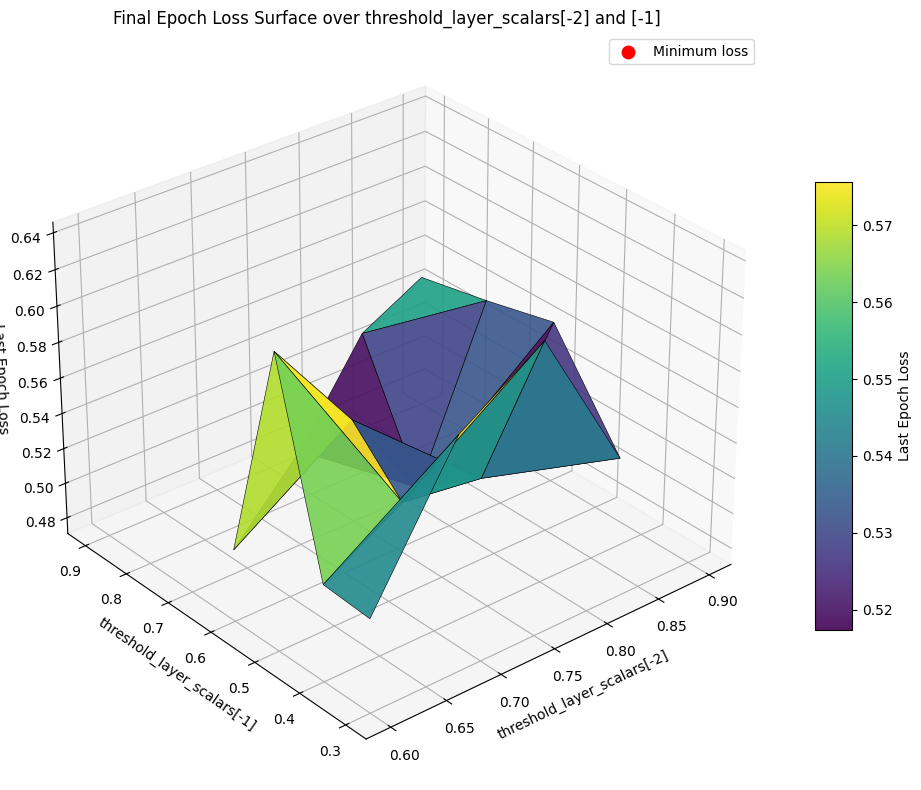

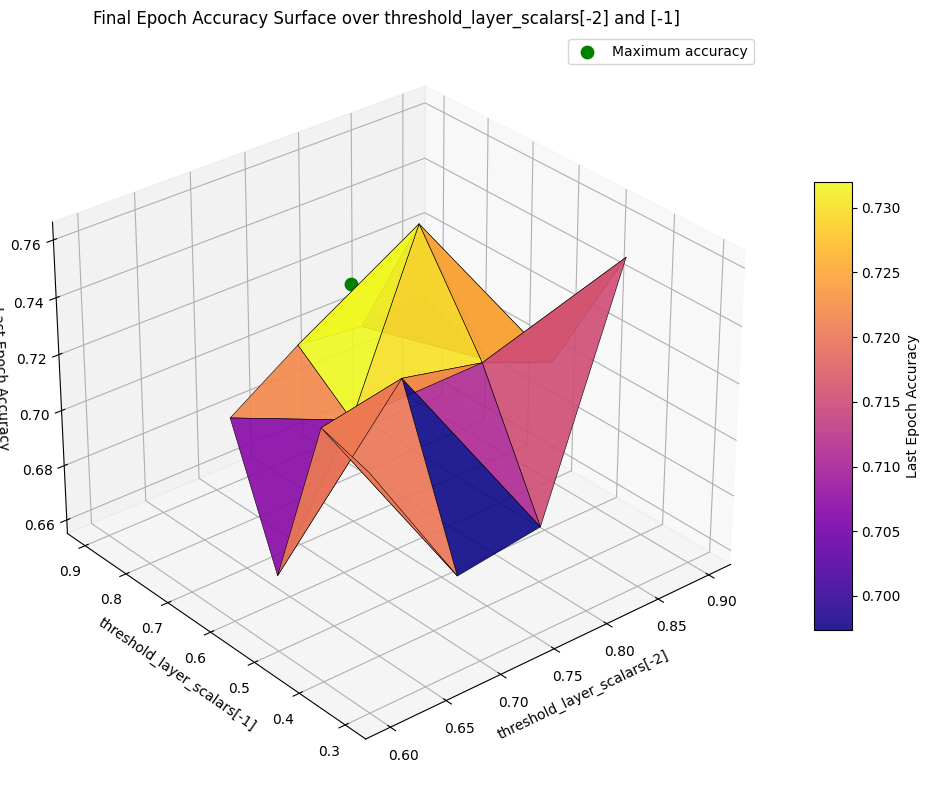

=== Best Parameter Combination (Minimum Last-Epoch Loss) ===
threshold_layer_scalars[-2]: 0.8
threshold_layer_scalars[-1]: 0.67
Last Epoch Loss: 0.481851
File: hypr-2_2026-04-27_21-18-52_e-10_s-25_spatial.json

=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===
threshold_layer_scalars[-2]: 0.7
threshold_layer_scalars[-1]: 0.58
Last Epoch Accuracy: 0.759000
File: hypr-2_2026-04-27_21-18-03_e-10_s-25_spatial.json

Accuracy key(s) used: ['epoch_train_accuracy']


In [14]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Build 3D surfaces of final-epoch metrics over last 2 threshold_layer_scalars values.
import numpy as np

files = sorted(glob('../output_results/E_sent/hypr-2/hypr-2_*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

# (scalar_m2, scalar_m1, last_epoch_loss, last_epoch_accuracy, file_name, acc_key_used)
records = []
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    threshold_layer_scalars_raw = training_config.get('threshold_layer_scalars')
    epoch_losses = results.get('epoch_train_loss', [])

    # Parse threshold_layer_scalars from string to list of floats
    threshold_layer_scalars = [float(x.strip()) for x in str(threshold_layer_scalars_raw).strip("[]").split(",")]

    accuracy_key_candidates = [
        'epoch_train_accuracy',
        'epoch_accuracy',
        'epoch_val_accuracy',
        'epoch_test_accuracy',
    ]
    last_acc = None
    acc_key_used = None
    for key in accuracy_key_candidates:
        series = results.get(key, [])
        if isinstance(series, list) and series:
            last_acc = float(series[-1])
            acc_key_used = key
            break

    if len(threshold_layer_scalars) < 2 or not epoch_losses or last_acc is None:
        continue

    scalar_m2 = threshold_layer_scalars[-2]
    scalar_m1 = threshold_layer_scalars[-1]
    last_epoch_loss = float(epoch_losses[-1])
    records.append((scalar_m2, scalar_m1, last_epoch_loss, last_acc, Path(file).name, acc_key_used))

if not records:
    raise ValueError(
        'No valid records found with threshold_layer_scalars (len>=2), epoch_train_loss, and an accuracy series.'
    )

# Extract x, y, z coordinates for triangulation
xs = np.array([r[0] for r in records])
ys = np.array([r[1] for r in records])
zs_loss = np.array([r[2] for r in records])
zs_acc = np.array([r[3] for r in records])

fig1 = plt.figure(figsize=(11, 8))
ax1 = fig1.add_subplot(111, projection='3d')
surf1 = ax1.plot_trisurf(xs, ys, zs_loss, cmap='viridis', edgecolor='k', linewidth=0.4, alpha=0.9)
fig1.colorbar(surf1, ax=ax1, shrink=0.6, aspect=12, label='Last Epoch Loss')

best_scalar_m2, best_scalar_m1, best_loss, _, best_loss_file, _ = min(records, key=lambda x: x[2])
ax1.scatter(best_scalar_m2, best_scalar_m1, best_loss, color='red', s=80, label='Minimum loss')
ax1.legend()

ax1.set_title('Final Epoch Loss Surface over threshold_layer_scalars[-2] and [-1]')
ax1.set_xlabel('threshold_layer_scalars[-2]')
ax1.set_ylabel('threshold_layer_scalars[-1]')
ax1.set_zlabel('Last Epoch Loss')
ax1.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(11, 8))
ax2 = fig2.add_subplot(111, projection='3d')
surf2 = ax2.plot_trisurf(xs, ys, zs_acc, cmap='plasma', edgecolor='k', linewidth=0.4, alpha=0.9)
fig2.colorbar(surf2, ax=ax2, shrink=0.6, aspect=12, label='Last Epoch Accuracy')

best_scalar_m2_acc, best_scalar_m1_acc, _, best_acc, best_acc_file, _ = max(records, key=lambda x: x[3])
ax2.scatter(best_scalar_m2_acc, best_scalar_m1_acc, best_acc, color='green', s=80, label='Maximum accuracy')
ax2.legend()

ax2.set_title('Final Epoch Accuracy Surface over threshold_layer_scalars[-2] and [-1]')
ax2.set_xlabel('threshold_layer_scalars[-2]')
ax2.set_ylabel('threshold_layer_scalars[-1]')
ax2.set_zlabel('Last Epoch Accuracy')
ax2.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

print('=== Best Parameter Combination (Minimum Last-Epoch Loss) ===')
print(f'threshold_layer_scalars[-2]: {best_scalar_m2}')
print(f'threshold_layer_scalars[-1]: {best_scalar_m1}')
print(f'Last Epoch Loss: {best_loss:.6f}')
print(f'File: {best_loss_file}')

print('\n=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===')
print(f'threshold_layer_scalars[-2]: {best_scalar_m2_acc}')
print(f'threshold_layer_scalars[-1]: {best_scalar_m1_acc}')
print(f'Last Epoch Accuracy: {best_acc:.6f}')
print(f'File: {best_acc_file}')

used_acc_keys = sorted({r[5] for r in records})
print(f'\nAccuracy key(s) used: {used_acc_keys}')

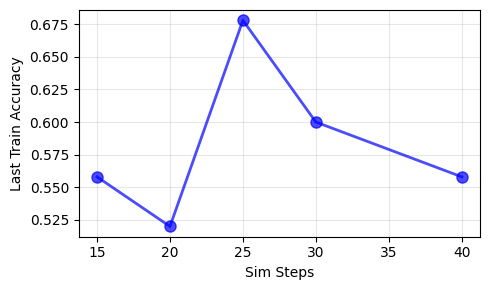

=== Highest Accuracy File ===
File: hypr-3_2026-04-28_13-16-34_e-10_s-25_temporal.json
Sim Steps: 25
Last Train Accuracy: 0.678000

learned_beta_values_by_layer:
  lif1: 0.8999999761581421
  lif2: 0.8999999761581421
  lif3: 0.8999999761581421


In [16]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# 2D line plot of last train accuracy vs sim_steps, with highest accuracy file details
import numpy as np

files = sorted(glob('../output_results/E_sent/hypr-3/hypr-3_*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

records = []
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})
    sim_steps_raw = training_config.get('sim_steps')

    last_acc = None
    series = results.get('epoch_train_accuracy', [])
    last_acc = float(series[-1])

    sim_steps = int(sim_steps_raw)
    records.append((sim_steps, last_acc, Path(file).name, file))

if not records:
    raise ValueError('No valid records found with sim_steps and an accuracy series.')

# Keep only the last record for each unique sim_steps value
sim_steps_to_record = {}
for sim_steps, last_acc, file_name, file_path in records:
    sim_steps_to_record[sim_steps] = (sim_steps, last_acc, file_name, file_path)

records_unique = sorted(sim_steps_to_record.values(), key=lambda x: x[0])

# Extract data for plotting
sim_steps_vals = np.array([r[0] for r in records_unique])
accuracies = np.array([r[1] for r in records_unique])

plt.figure(figsize=(5, 3))
plt.plot(sim_steps_vals, accuracies, marker='o', linewidth=2, markersize=8, color='blue', alpha=0.7)
plt.xlabel('Sim Steps')
plt.ylabel('Last Train Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find highest accuracy record and print learned_beta_values_by_layer
best_sim_steps, best_acc, best_file_name, best_file_path = max(records, key=lambda x: x[1])

print('=== Highest Accuracy File ===')
print(f'File: {best_file_name}')
print(f'Sim Steps: {best_sim_steps:g}')
print(f'Last Train Accuracy: {best_acc:.6f}')

# Load the best file and extract learned_beta_values_by_layer
with open(best_file_path, 'r', encoding='utf-8') as f:
    best_data = json.load(f).get('results', {})

    learned_beta = best_data.get('learned_beta_values_by_layer')
    if learned_beta is not None:
        print(f'\nlearned_beta_values_by_layer:')
        if isinstance(learned_beta, dict):
            for layer, value in learned_beta.items():
                print(f'  {layer}: {value}')
        else:
            print(f'  {learned_beta}')
    else:
        print('\nlearned_beta_values_by_layer: Not found in results')